/var/folders/cp/m7f9rhc50r33spmntt84ml140000gn/T/ipykernel_17575/4264753206.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  xrate = yf.download("USDIDR=X", start=date_start, end=date_end)
[*********************100%***********************]  1 of 1 completed
/var/folders/cp/m7f9rhc50r33spmntt84ml140000gn/T/ipykernel_17575/4264753206.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  usd_index = yf.download("DX-Y.NYB", start=date_start, end=date_end)
[*********************100%***********************]  1 of 1 completed
/var/folders/cp/m7f9rhc50r33spmntt84ml140000gn/T/ipykernel_17575/4264753206.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil = yf.download("CL=F", start=date_start, end=date_end)
[*********************100%***********************]  1 of 1 completed
/var/folders/cp/m7f9rhc50r33spmntt84ml140000gn/T/ipykernel_17575/4264753206.py:16: FutureWarning: YF.download() ha

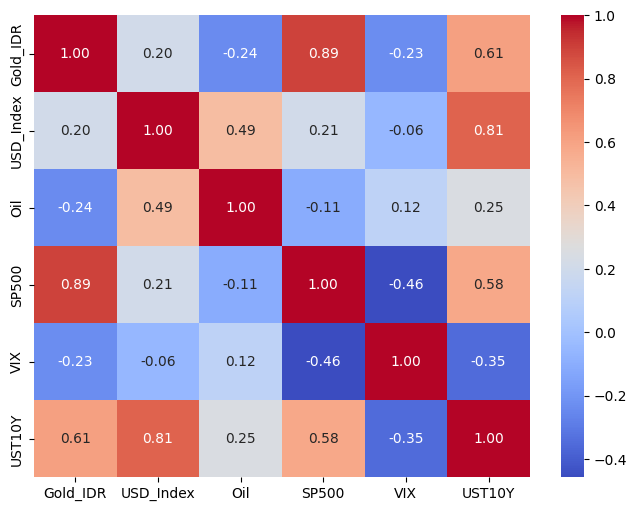

NameError: name 'Prophet' is not defined

In [2]:
import yfinance as yf
import pandas as pd
import numpy as num
import prophet as prophet
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:.2f}'.format)
date_start = '2020-10-01'
date_end = '2025-10-01'

xrate = yf.download("USDIDR=X", start=date_start, end=date_end)

usd_index = yf.download("DX-Y.NYB", start=date_start, end=date_end)
oil = yf.download("CL=F", start=date_start, end=date_end)
sp500 = yf.download("^GSPC", start=date_start, end=date_end)
vix = yf.download("^VIX", start=date_start, end=date_end)
tnx = yf.download("^TNX", start=date_start, end=date_end)

gold = yf.download("GC=F", start=date_start, end=date_end)
gold = gold / 31.1035

merge = gold.join(xrate,lsuffix= '_gold', rsuffix = '_xrate') 
merge_idr = pd.DataFrame()
price_col = ['Close', 'High', 'Low', 'Open']
for col in price_col:
    merge_idr[col+ '_IDR'] = merge[(col,'GC=F')] * merge[(col, 'USDIDR=X')]

datasets = [xrate, usd_index, oil, sp500, vix, tnx]

for i in range(len(datasets)):
    if isinstance(datasets[i].columns, pd.MultiIndex):
        datasets[i].columns = datasets[i].columns.get_level_values(0)
    
corr_df = pd.DataFrame()
corr_df['Gold_IDR'] = merge_idr['Close_IDR']
corr_df['USD_Index'] = usd_index['Close']
corr_df['Oil'] = oil['Close']
corr_df['SP500'] = sp500['Close']
corr_df['VIX'] = vix['Close']
corr_df['UST10Y'] = tnx['Close']


corr_df = corr_df.dropna()

corr = corr_df[['Gold_IDR','USD_Index','Oil','SP500','VIX','UST10Y']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

merge_idr = merge_idr.reset_index()
df = merge_idr[['Date', 'Close_IDR']].rename(columns={'Date': 'ds', 'Close_IDR': 'y'})
df = merge_idr[['Date', 'Close_IDR']].rename(columns={'Date': 'ds', 'Close_IDR': 'y'})
df['usd_index'] = usd_index['Close'].shift(3).values
df['oil'] = oil['Close'].shift(3).values
df = df.dropna()

model = Prophet(
    changepoint_prior_scale=0.3,   # more reactive to trend changes
    seasonality_prior_scale=10,
    yearly_seasonality=True,
    weekly_seasonality=False
)

model.fit(df)

future = model.make_future_dataframe(periods=90)
future['usd_index'] = usd_index['Close'].reindex(future['ds']).fillna(method='ffill').values
future['oil'] = oil['Close'].reindex(future['ds']).fillna(method='ffill').values

forecast = model.predict(future)

from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(model, initial='1095 days', period='180 days', horizon='365 days')
perf = performance_metrics(df_cv)
perf[['horizon', 'mae', 'rmse', 'mape']].head()
